# plot argon data from Shakleton et al

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
path_to_sample_master = '../../data/sampling/master/'
path_to_broader_context = '../../data/broader_context/'
path_to_final_figures = '../../../paper/final_figures/'


In [15]:
# import data - raymo
bdf = pd.read_csv(path_to_broader_context + 'lisiecki2005-d18o-stack-noaa.csv',skiprows=126)
bdf.head()

,age_calkaBP,d18O_benthic,d18O_error
0,0.0,3.23,0.03
1,1.0,3.23,0.04
2,2.0,3.18,0.03
3,3.0,3.29,0.03
4,4.0,3.30,0.03


In [16]:
# import data - mine
df = pd.read_csv(path_to_sample_master + 'age_master.csv')
#rename d18O_meltwater to d18O
df = df.rename(columns={'d18O_meltwater': 'd18O'})
df.head()

,section,stick,default_color,top_depth,bottom_depth,mid_depth,top_depth_adj,bottom_depth_adj,mid_depth_adj,age,d18O,dD_meltwater
0,228_4,Ar,8,155.136430,155.234998,155.189827,155.052026,155.166208,155.114968,1.3691,-36.50,-289.94
1,228_4,Ar,8,155.110001,155.150000,155.128922,155.037492,155.166310,155.105205,1.5319,-36.46,-289.35
2,228_4,Ar,8,155.140000,155.230000,155.190469,155.139156,155.273441,155.200150,1.6768,-36.98,-294.56
3,228_4,Ar,8,155.230000,155.309999,155.264805,155.146564,155.273365,155.217865,1.7847,-37.00,-294.90
4,228_4,Ar,8,155.231619,155.309999,155.281658,155.248616,155.360368,155.296533,1.6561,NaN,NaN


In [17]:
# import data - shackleton
sdf = pd.read_excel(path_to_broader_context + 'shackleton.xlsx', sheet_name='Ar and Water isotopes')
# delete the first row
sdf = sdf.iloc[1:]
# delete rows where Age or d18O ice is nan
sdf = sdf[sdf['Age'].notna() & sdf['d18Oice'].notna()]
# rename Age to aage and d18Oice to d18O
sdf = sdf.rename(columns={'Age': 'age', 'd18Oice': 'd18O'})
sdf['age'] = sdf['age'].astype(float)*1000  # convert to kyr
sdf.head()



,Core,top depth,d40/38Ar,std,d38/36Ar,std.1,40ArATM,std.2,age,Relative err,...,dArN2,std.5,d18O,dDice,dxs,snapshot,Reference,Unnamed: 23,Unnamed: 24,Unnamed: 25
1,ALHIC1502,35.27,0.130437,-,0.130461,-,-0.023,0.006,350.0,0.090909,...,NaN,NaN,-35.55936,-283.0578,1.41708,short,"Yan et al., 2019",NaN,NaN,NaN
2,ALHIC1502,79.02,0.181377,-,0.206716,-,-0.038,0.006,570.0,0.090909,...,NaN,NaN,-37.64088,-300.867,0.26004,short,"Yan et al., 2019",NaN,NaN,NaN
4,ALHIC1502,142.91,0.237681,-,0.264102,-,-0.035,0.006,530.0,0.090909,...,NaN,NaN,-35.95584,-288.9942,-1.34748,short,"Yan et al., 2019",NaN,NaN,NaN
5,ALHIC1502,171.73,0.120922,-,0.156014,-,-0.05,0.006,750.0,0.090909,...,NaN,NaN,-38.33472,-305.814,0.86376,short,"Yan et al., 2019",NaN,NaN,NaN
6,ALHIC1502,174.2,0.1034,-,0.1452,-,-0.042,0.006,640.0,0.090909,...,NaN,NaN,-37.74,-300.867,1.053,short,"Yan et al., 2019",NaN,NaN,NaN


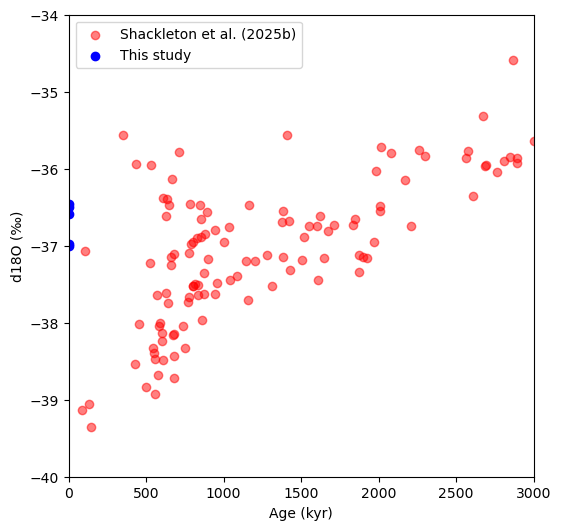

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(sdf['age'], sdf['d18O'], label='Shackleton et al. (2025b)', color='red', alpha=0.5)
ax.scatter(df['age'], df['d18O'], label='This study', color='blue', alpha=1)
ax.set_xlabel('Age (kyr)')
ax.set_ylabel('d18O (‰)')
ax.set_xlim(0,3000)
ax.set_ylim(-40,-34)
ax.legend()

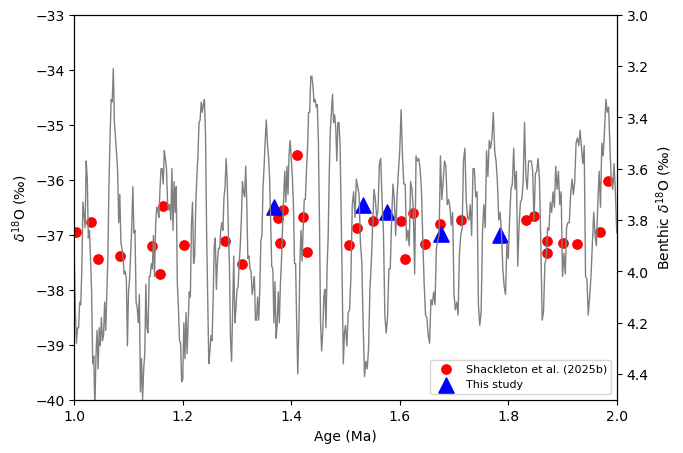

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
ax_right = ax.twinx()

ax.set_xlabel('Age (Ma)')
ax.set_ylabel('$\delta^{18}$O (‰)')
ax_right.set_ylabel('Benthic $\delta^{18}$O (‰)')

ax_right.plot(bdf['age_calkaBP']/1000, bdf['d18O_benthic'], color='grey', linewidth=1, label='Lisiecki & Raymo (2005)')

ax.scatter(sdf['age']/1000, sdf['d18O'], label='Shackleton et al. (2025b)', color='red', alpha=1,s=180,marker='.')
ax.scatter(df['age'], df['d18O'], label='This study', color='blue', alpha=1,s=120,marker='^')

ax.set_xlim(1,2)
ax.set_ylim(-40,-33)
ax_right.set_ylim(4.5,3)


h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_right.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='lower right')
# set legend font size to 8
ax.legend(loc='lower right', fontsize=8)

# save final figure as pdf and png
fig.savefig(path_to_final_figures+'pdf/figure10.pdf', dpi=300)
fig.savefig(path_to_final_figures+'png/figure10.png', dpi=300)

In [20]:
# add a right-side y-axis and plot benthic d18O from bdf as a continuous grey line
ax_right = ax.twinx()

# convert columns to numeric (age in col 0, d18O in col 1) and drop NA pairs

ax_right.plot(bdf['age_calkaBP'], bdf['d18O_benthic'], color='grey', linewidth=1, label='Lisiecki & Raymo (2005)')

# style right axis
ax_right.set_ylabel('d18O_benthic (‰)', color='grey')
ax_right.tick_params(axis='y', colors='grey')
ax_right.spines['right'].set_color('grey')

# combine legends from both axes
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_right.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper right')